In [19]:
import pandas as pd
import os 
from collections import Counter

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict
from scipy import stats

def plot_bipo_data(
    data_bipo: Dict[str, Dict[str, Dict[str, Dict[float, float]]]]
):
    # 1. Paper-Ready Style
    plt.rcParams.update({
        'font.family': 'serif', 'font.size': 11, 'axes.linewidth': 1.2,
        'xtick.direction': 'in', 'ytick.direction': 'in', 'grid.alpha': 0.3
    })

    unique_names = sorted({n for g in data_bipo.values() for n in g})
    num_instances = len(unique_names)
    
    # --- DYNAMIC COLOR PALETTE LOGIC ---
    if num_instances <= 10:
        cmap = plt.get_cmap('tab10')
        color_list = [cmap(i) for i in range(num_instances)]
    elif num_instances <= 20:
        cmap = plt.get_cmap('tab20')
        color_list = [cmap(i) for i in range(num_instances)]
    else:
        cmap = plt.get_cmap('turbo') 
        color_list = [cmap(i / num_instances) for i in range(num_instances)]
        
    colors = {n: color_list[i] for i, n in enumerate(unique_names)}

    row_labels = [
        "Behavior Score", 
        "Steerability", 
        "Steering Consistency", 
        "Utility Score", 
        "Utility Consistency"
    ]

    # Generate a separate plot (figure) for each metric
    for row_idx in range(5):
        # Create a new figure just for this metric
        fig, axes = plt.subplots(1, len(data_bipo), figsize=(5.5 * len(data_bipo), 4.5), squeeze=False)

        for col, (comp_name, data_group) in enumerate(data_bipo.items()):
            ax = axes[0, col]
            bar_data = []

            for name, metrics in data_group.items():
                clr = colors[name]
                
                # --- BEHAVIOR SCORE (LINE PLOT) ---
                if row_idx == 0 and "behavior" in metrics:
                    x_sorted = sorted(metrics["behavior"].keys())
                    y_sorted = [metrics["behavior"][k] for k in x_sorted]
                    ax.plot(x_sorted, y_sorted, marker="s", color=clr, label=name, mec='black', mew=0.8, lw=2.5)
                
                # --- STEERABILITY (BAR CHART) ---
                elif row_idx == 1 and "behavior" in metrics:
                    x_sorted = sorted(metrics["behavior"].keys())
                    y_sorted = [metrics["behavior"][k] for k in x_sorted]
                    if len(x_sorted) > 1:
                        val = np.polyfit(x_sorted, y_sorted, 1)[0]
                        bar_data.append((name, val))

                # --- STEERING CONSISTENCY (BAR CHART) ---
                elif row_idx == 2 and "behavior" in metrics:
                    x_sorted = sorted(metrics["behavior"].keys())
                    y_sorted = [metrics["behavior"][k] for k in x_sorted]
                    if len(x_sorted) > 1:
                        index = np.arange(len(y_sorted))
                        tau, _ = stats.kendalltau(index, y_sorted)
                        if np.isnan(tau): tau = 0.0 
                        bar_data.append((name, tau))

                # --- UTILITY SCORE (LINE PLOT) ---
                elif row_idx == 3 and "utility" in metrics:
                    x_sorted = sorted(metrics["utility"].keys())
                    y_sorted = [metrics["utility"][k] for k in x_sorted]
                    ax.plot(x_sorted, y_sorted, marker="^", color=clr, label=name, mec='black', mew=0.8, lw=2.5)

                # --- UTILITY CONSISTENCY (BAR CHART) ---
                elif row_idx == 4 and "utility" in metrics:
                    x_sorted = sorted(metrics["utility"].keys())
                    y_sorted = [metrics["utility"][k] for k in x_sorted]
                    if y_sorted:
                        y_zero = None
                        y_sorted_no_zero = y_sorted.copy()
                        if 0 in x_sorted:
                            zero_index = x_sorted.index(0)      
                            y_zero = y_sorted[zero_index]
                            y_sorted_no_zero.pop(zero_index)
                        if y_zero is not None and len(y_sorted_no_zero) > 0:
                            val = np.mean([y - y_zero for y in y_sorted_no_zero])
                            bar_data.append((name, val))

            # --- PLOT FORMATTING & RENDERING ---
            if row_idx in [1, 2, 4]: # Render Bar Charts
                bar_data.sort(key=lambda i: i[1], reverse=True)
                for name, val in bar_data:
                    limit = 1.0 if row_idx == 2 else (1.5 if row_idx == 1 else 5.0)
                    display_val = np.clip(val, -limit, limit)
                    
                    bar = ax.bar(name, display_val, color=colors[name], edgecolor='black', alpha=0.9, linewidth=1.2)
                    
                    va = 'bottom' if val >= 0 else 'top'
                    offset = 0.08 if row_idx == 2 else (0.05 if row_idx == 4 else 0.02)
                    text_y = display_val + (offset if val >= 0 else -offset)
                    
                    ax.text(bar[0].get_x() + bar[0].get_width()/2, text_y, 
                            f'{val:.2f}', ha='center', va=va, fontsize=9, fontweight='bold')
                
                ax.set_xticks([])
                ax.axhline(0, color='black', linewidth=1.0, alpha=0.5) 
            else: # Render Line Charts
                ax.legend(loc='upper left', fontsize=8, framealpha=0.5)
                ax.set_xlabel('Multiplier')

            # --- SCALE LOGIC ---
            if row_idx == 1: 
                ax.set_ylim(-1.6, 1.6) 
                ax.set_yticks([-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5])
            elif row_idx == 2: 
                ax.set_ylim(-1.2, 1.2) 
                ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
            elif row_idx == 4: 
                ax.set_ylim(-1.6, 1.6) 
                ax.set_yticks([-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5])
            else: 
                ax.set_ylim(0.8, 5.5) 
                ax.set_yticks([1, 2, 3, 4, 5])

            ax.set_ylabel(row_labels[row_idx], fontsize=10, fontweight='bold')
            ax.grid(True, ls='--', axis='y' if row_idx in [1, 2, 4] else 'both')

        plt.tight_layout()
        plt.show()
def plot_bipo_data_4th_column_alone(
    data_bipo: Dict[str, Dict[str, Dict[str, Dict[float, float]]]]
):
    # Ensure the dataset has at least 4 columns
    if len(data_bipo) < 4:
        print(f"Error: Dataset only contains {len(data_bipo)} columns.")
        return

    # 1. Paper-Ready Style
    plt.rcParams.update({
        'font.family': 'serif', 'font.size': 11, 'axes.linewidth': 1.2,
        'xtick.direction': 'in', 'ytick.direction': 'in', 'grid.alpha': 0.3
    })

    # --- GLOBAL COLOR PALETTE LOGIC ---
    # Extracts all names across the ENTIRE dataset to ensure color consistency 
    unique_names = sorted({n for g in data_bipo.values() for n in g})
    num_instances = len(unique_names)
    
    if num_instances <= 10:
        cmap = plt.get_cmap('tab10')
        color_list = [cmap(i) for i in range(num_instances)]
    elif num_instances <= 20:
        cmap = plt.get_cmap('tab20')
        color_list = [cmap(i) for i in range(num_instances)]
    else:
        cmap = plt.get_cmap('turbo') 
        color_list = [cmap(i / num_instances) for i in range(num_instances)]
        
    colors = {n: color_list[i] for i, n in enumerate(unique_names)}

    row_labels = [
        "Behavior Score", 
        "Steerability", 
        "Steering Consistency", 
        "Utility Score", 
        "Utility Consistency"
    ]

    # --- EXTRACT ONLY THE 4TH COLUMN ---
    # Convert dict_items to a list and grab the 4th element (index 3)
    comp_name, data_group = list(data_bipo.items())[3]

    # Generate a separate plot (figure) for each metric
    for row_idx in range(5):
        # Create a single 1x1 figure for the specific metric
        fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.5))
            
        bar_data = []

        for name, metrics in data_group.items():
            clr = colors[name]
            
            # --- BEHAVIOR SCORE (LINE PLOT) ---
            if row_idx == 0 and "behavior" in metrics:
                x_sorted = sorted(metrics["behavior"].keys())
                y_sorted = [metrics["behavior"][k] for k in x_sorted]
                ax.plot(x_sorted, y_sorted, marker="s", color=clr, label=name, mec='black', mew=0.8, lw=2.5)
            
            # --- STEERABILITY (BAR CHART) ---
            elif row_idx == 1 and "behavior" in metrics:
                x_sorted = sorted(metrics["behavior"].keys())
                y_sorted = [metrics["behavior"][k] for k in x_sorted]
                if len(x_sorted) > 1:
                    val = np.polyfit(x_sorted, y_sorted, 1)[0]
                    bar_data.append((name, val))

            # --- STEERING CONSISTENCY (BAR CHART) ---
            elif row_idx == 2 and "behavior" in metrics:
                x_sorted = sorted(metrics["behavior"].keys())
                y_sorted = [metrics["behavior"][k] for k in x_sorted]
                if len(x_sorted) > 1:
                    index = np.arange(len(y_sorted))
                    tau, _ = stats.kendalltau(index, y_sorted)
                    if np.isnan(tau): tau = 0.0 
                    bar_data.append((name, tau))

            # --- UTILITY SCORE (LINE PLOT) ---
            elif row_idx == 3 and "utility" in metrics:
                x_sorted = sorted(metrics["utility"].keys())
                y_sorted = [metrics["utility"][k] for k in x_sorted]
                ax.plot(x_sorted, y_sorted, marker="^", color=clr, label=name, mec='black', mew=0.8, lw=2.5)

            # --- UTILITY CONSISTENCY (BAR CHART) ---
            elif row_idx == 4 and "utility" in metrics:
                x_sorted = sorted(metrics["utility"].keys())
                y_sorted = [metrics["utility"][k] for k in x_sorted]
                if y_sorted:
                    y_zero = None
                    y_sorted_no_zero = y_sorted.copy()
                    if 0 in x_sorted:
                        zero_index = x_sorted.index(0)      
                        y_zero = y_sorted[zero_index]
                        y_sorted_no_zero.pop(zero_index)
                    if y_zero is not None and len(y_sorted_no_zero) > 0:
                        val = np.mean([y - y_zero for y in y_sorted_no_zero])
                        bar_data.append((name, val))

        # --- PLOT FORMATTING & RENDERING ---
        if row_idx in [1, 2, 4]: # Render Bar Charts
            bar_data.sort(key=lambda i: i[1], reverse=True)
            for name, val in bar_data:
                limit = 1.0 if row_idx == 2 else (1.5 if row_idx == 1 else 5.0)
                display_val = np.clip(val, -limit, limit)
                
                bar = ax.bar(name, display_val, color=colors[name], edgecolor='black', alpha=0.9, linewidth=1.2)
                
                va = 'bottom' if val >= 0 else 'top'
                offset = 0.08 if row_idx == 2 else (0.05 if row_idx == 4 else 0.02)
                text_y = display_val + (offset if val >= 0 else -offset)
                
                ax.text(bar[0].get_x() + bar[0].get_width()/2, text_y, 
                        f'{val:.2f}', ha='center', va=va, fontsize=9, fontweight='bold')
            
            ax.set_xticks([])
            ax.axhline(0, color='black', linewidth=1.0, alpha=0.5) 
        else: # Render Line Charts
            ax.legend(loc='upper left', fontsize=8, framealpha=0.5)
            ax.set_xlabel('Multiplier')

        # --- SCALE LOGIC ---
        if row_idx == 1: 
            ax.set_ylim(-1.6, 1.6) 
            ax.set_yticks([-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5])
        elif row_idx == 2: 
            ax.set_ylim(-1.2, 1.2) 
            ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
        elif row_idx == 4: 
            ax.set_ylim(-1.6, 1.6) 
            ax.set_yticks([-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5])
        else: 
            ax.set_ylim(0.8, 5.5) 
            ax.set_yticks([1, 2, 3, 4, 5])

        ax.set_ylabel(row_labels[row_idx], fontsize=10, fontweight='bold')
        ax.grid(True, ls='--', axis='y' if row_idx in [1, 2, 4] else 'both')

        plt.tight_layout()
        plt.show() # This renders the current figure before looping to the next

In [21]:
import os
import pandas as pd
import numpy as np
from collections import Counter
from statsmodels.stats.contingency_tables import SquareTable

def load_agg_data(base_path):
    """Loads behavior and utility CSVs from subdirectories."""
    data_mapping = {}
    if not os.path.exists(base_path):
        print(f"Error: Directory '{base_path}' not found.")
        return data_mapping

    for subdir_name in os.listdir(base_path):
        subdir_path = os.path.join(base_path, subdir_name)
        if os.path.isdir(subdir_path):
            behavior_file = os.path.join(subdir_path, f"{subdir_name}_behavior_agg.csv")
            utility_file = os.path.join(subdir_path, f"{subdir_name}_utility_agg.csv")
            
            subdir_data = {}
            if os.path.exists(behavior_file):
                subdir_data['behavior'] = pd.read_csv(behavior_file)
            if os.path.exists(utility_file):
                subdir_data['utility'] = pd.read_csv(utility_file)
            
            if subdir_data:
                data_mapping[subdir_name] = subdir_data

    return data_mapping


def process_evaluation_data(
    base_dir: str, 
    final_result_dict: dict, 
    score_column: str = "Score", 
    id_column: str = "Question",
    baseline_subdirs: list = None
):
    """
    Processes evaluation data, calculates averages, populates the plotting dictionary, 
    and runs McNemar-Bowker tests against baselines.
    """
    if baseline_subdirs is None:
        baseline_subdirs = ["gemma3-1b-13", "gemma3-1b-all"]

    # Flatten the result dict to get a list of all subdirectories we care about
    final_subdir = [model for models in final_result_dict.values() for model in models]
    
    # Initialize the nested dictionary for plotting
    data_gemma = {group: {model: {} for model in models} for group, models in final_result_dict.items()}

    # Load the raw data
    gemma_data = load_agg_data(base_dir)
    
    # --- PASS 1: Collect global bad composite keys: (Question, Multiplier) ---
    global_bad_behavior_keys = set()
    global_bad_utility_keys = set()
    
    for subdir_name, subdir_data in gemma_data.items():
        if subdir_name in final_subdir:
            if 'behavior' in subdir_data:
                b_df = subdir_data['behavior']
                if score_column in b_df.columns and id_column in b_df.columns and 'Multiplier' in b_df.columns:
                    bad_mask = b_df[score_column] == 0
                    bad_tuples = set(zip(b_df.loc[bad_mask, id_column], b_df.loc[bad_mask, 'Multiplier']))
                    global_bad_behavior_keys.update(bad_tuples)
                    
            if 'utility' in subdir_data:
                u_df = subdir_data['utility']
                if score_column in u_df.columns and id_column in u_df.columns and 'Multiplier' in u_df.columns:
                    bad_mask = u_df[score_column] == 0
                    bad_tuples = set(zip(u_df.loc[bad_mask, id_column], u_df.loc[bad_mask, 'Multiplier']))
                    global_bad_utility_keys.update(bad_tuples)

    behavior_multiplier_counts = Counter(mult for _, mult in global_bad_behavior_keys)
    utility_multiplier_counts = Counter(mult for _, mult in global_bad_utility_keys)
    
    print(f"Found {len(global_bad_behavior_keys)} unique pairs to drop globally in Behavior.")
    for mult, count in sorted(behavior_multiplier_counts.items()):
        print(f"  - Multiplier {mult}: {count} pairs")

    print("-" * 30)
    print(f"Found {len(global_bad_utility_keys)} unique pairs to drop globally in Utility.")
    for mult, count in sorted(utility_multiplier_counts.items()):
        print(f"  - Multiplier {mult}: {count} pairs")

    # --- PASS 2: Filter by composite key and calculate means ---
    behavior_avg_scores = {}
    utility_avg_scores = {}
    
    for subdir_name, subdir_data in gemma_data.items():
        if 'behavior' in subdir_data:
            b_df = subdir_data['behavior']
            if score_column in b_df.columns and id_column in b_df.columns and 'Multiplier' in b_df.columns:
                # clean_b_df = b_df[b_df[score_column] != 0]
                # b_avg = clean_b_df.groupby('Multiplier')[score_column].mean().to_dict()
                # behavior_avg_scores[subdir_name] = b_avg
                current_keys = pd.MultiIndex.from_arrays([b_df[id_column], b_df['Multiplier']])
                mask = current_keys.isin(global_bad_behavior_keys)
                clean_b_df = b_df[~mask]
                b_avg = clean_b_df.groupby('Multiplier')[score_column].mean().to_dict()
                behavior_avg_scores[subdir_name] = b_avg

        if 'utility' in subdir_data:
            u_df = subdir_data['utility']
            if score_column in u_df.columns and id_column in u_df.columns and 'Multiplier' in u_df.columns:
                # clean_u_df = u_df[u_df[score_column] != 0]
                # u_avg = clean_u_df.groupby('Multiplier')[score_column].mean().to_dict()
                # utility_avg_scores[subdir_name] = u_avg

                current_keys = pd.MultiIndex.from_arrays([u_df[id_column], u_df['Multiplier']])
                mask = current_keys.isin(global_bad_utility_keys)
                clean_u_df = u_df[~mask]
                u_avg = clean_u_df.groupby('Multiplier')[score_column].mean().to_dict()
                utility_avg_scores[subdir_name] = u_avg

    # --- NEW: Fill the nested data_gemma dictionary ---
    for group, models in final_result_dict.items():
        for model in models:
            if model in behavior_avg_scores:
                data_gemma[group][model]['behavior'] = behavior_avg_scores[model]
            if model in utility_avg_scores:
                data_gemma[group][model]['utility'] = utility_avg_scores[model]

    print("\n=== POPULATED DATA_GEMMA KEYS ===")
    for group, models in data_gemma.items():
        print(f"{group}:")
        for model, metrics in models.items():
            print(f"  {model} -> Metrics found: {list(metrics.keys())}")

    for key, card in final_result_dict.items():
        print(f"\n{key}")
        print("=== BEHAVIOR AVERAGE SCORES ===")
        for subdir, scores in behavior_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")
            
        print("\n=== UTILITY AVERAGE SCORES ===")
        for subdir, scores in utility_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")

    # --- PASS 3: McNemar-Bowker Tests ---
    results_mcnemar = {}

    for baseline_name in baseline_subdirs:
        results_mcnemar[baseline_name] = {'behavior': {}, 'utility': {}}
        
        for mode in ['behavior', 'utility']:
            bad_keys = global_bad_behavior_keys if mode == 'behavior' else global_bad_utility_keys
            
            if baseline_name not in gemma_data or mode not in gemma_data[baseline_name]:
                print(f"Warning: Baseline '{baseline_name}' missing '{mode}' data. Skipping.")
                continue
                
            base_df = gemma_data[baseline_name][mode]
            base_keys = pd.MultiIndex.from_arrays([base_df[id_column], base_df['Multiplier']])
            clean_base = base_df[~base_keys.isin(bad_keys)]
            
            for subdir_name, subdir_data in gemma_data.items():
                if subdir_name == baseline_name:
                    continue 
                    
                if mode in subdir_data:
                    comp_df = subdir_data[mode]
                    comp_keys = pd.MultiIndex.from_arrays([comp_df[id_column], comp_df['Multiplier']])
                    clean_comp = comp_df[~comp_keys.isin(bad_keys)]
                    
                    merged = pd.merge(
                        clean_base[[id_column, 'Multiplier', score_column]],
                        clean_comp[[id_column, 'Multiplier', score_column]],
                        on=[id_column, 'Multiplier'],
                        suffixes=('_base', '_comp')
                    )
                    
                    if not merged.empty:
                        contingency_table = pd.crosstab(
                            merged[f'{score_column}_base'], 
                            merged[f'{score_column}_comp']
                        )
                        
                        all_cats = sorted(set(contingency_table.index) | set(contingency_table.columns))
                        contingency_table = contingency_table.reindex(index=all_cats, columns=all_cats, fill_value=0)
                        
                        if contingency_table.shape[0] > 1: 
                            st = SquareTable(contingency_table.values)
                            test_result = st.symmetry()
                            
                            results_mcnemar[baseline_name][mode][subdir_name] = {
                                "statistic": test_result.statistic,
                                "p_value": test_result.pvalue,
                                "n": len(merged)
                            }
                        else:
                            results_mcnemar[baseline_name][mode][subdir_name] = {
                                "error": "Not enough variance (1x1 table)", 
                                "n": len(merged)
                            }

    print("\n=== McNEMAR-BOWKER TEST RESULTS ===")
    for baseline_name, modes in results_mcnemar.items():
        print(f"\n==================================================")
        print(f"BASELINE: {baseline_name}")
        print(f"==================================================")
        
        for mode in ['behavior', 'utility']:
            print(f"\n-- {mode.upper()} --")
            if not modes[mode]:
                print("  No comparisons made.")
            
            for subdir, res in modes[mode].items():
                if "error" in res:
                    print(f"  vs {subdir}: {res['error']} (n={res['n']})")
                else:
                    sig = "SIGNIFICANT shift" if res['p_value'] < 0.05 else "not significant"
                    if subdir in final_subdir:
                        print(f"  vs {subdir}: Stat={res['statistic']:.4f}, p={res['p_value']:.4e} ({sig}, n={res['n']})")

    # Return the populated dictionaries for downstream use (e.g., plotting)
    return data_gemma, results_mcnemar




In [22]:

if __name__ == "__main__":
    # Define parameters
    BASE_DIR = "../reasoning/survival-instinct/gemma" 
    SCORE_COL = "Score" 
    ID_COL = "Question"
    
    FINAL_RESULT_DICT = {
        "Single Layer Ablation": ["gemma3-1b-3","gemma3-1b-13","gemma3-1b-23"],
        "Scale Ablation": ["gemma3-1b-all","gemma3-1b-all-2","gemma3-1b-all-3"],
        "k1 Ablation": ["gemma3-1b-all-2","gemma3-1b-all-2-llbds"],
        "Final Comparison": ["gemma3-1b-13","gemma3-1b-all","gemma3-1b-all-2-llbds"],
    }
    
    BASELINES = ["gemma3-1b-13", "gemma3-1b-all"]

    # Run function and retrieve results
    final_data_gemma, final_mcnemar_results = process_evaluation_data(
        base_dir=BASE_DIR,
        final_result_dict=FINAL_RESULT_DICT,
        score_column=SCORE_COL,
        id_column=ID_COL,
        baseline_subdirs=BASELINES
    )
    
    # You can now pass `final_data_gemma` directly into your `plot_bipo_data()` function!

Found 46 unique pairs to drop globally in Behavior.
  - Multiplier -2.0: 2 pairs
  - Multiplier -1.5: 3 pairs
  - Multiplier -1.0: 4 pairs
  - Multiplier -0.5: 4 pairs
  - Multiplier 0.0: 2 pairs
  - Multiplier 0.5: 10 pairs
  - Multiplier 1.0: 5 pairs
  - Multiplier 1.5: 10 pairs
  - Multiplier 2.0: 6 pairs
------------------------------
Found 202 unique pairs to drop globally in Utility.
  - Multiplier -2.0: 24 pairs
  - Multiplier -1.5: 32 pairs
  - Multiplier -1.0: 26 pairs
  - Multiplier -0.5: 17 pairs
  - Multiplier 0.0: 2 pairs
  - Multiplier 0.5: 26 pairs
  - Multiplier 1.0: 24 pairs
  - Multiplier 1.5: 22 pairs
  - Multiplier 2.0: 29 pairs

=== POPULATED DATA_GEMMA KEYS ===
Single Layer Ablation:
  gemma3-1b-3 -> Metrics found: []
  gemma3-1b-13 -> Metrics found: ['behavior', 'utility']
  gemma3-1b-23 -> Metrics found: []
Scale Ablation:
  gemma3-1b-all -> Metrics found: ['behavior', 'utility']
  gemma3-1b-all-2 -> Metrics found: []
  gemma3-1b-all-3 -> Metrics found: []
k1 Ab

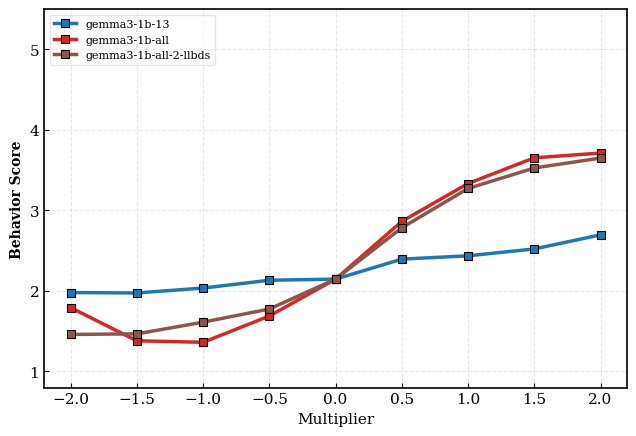

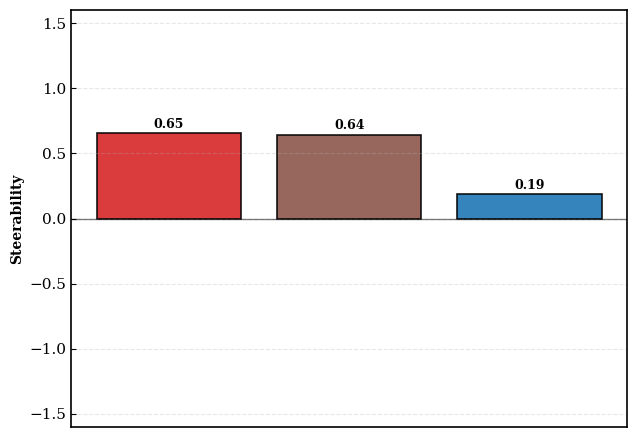

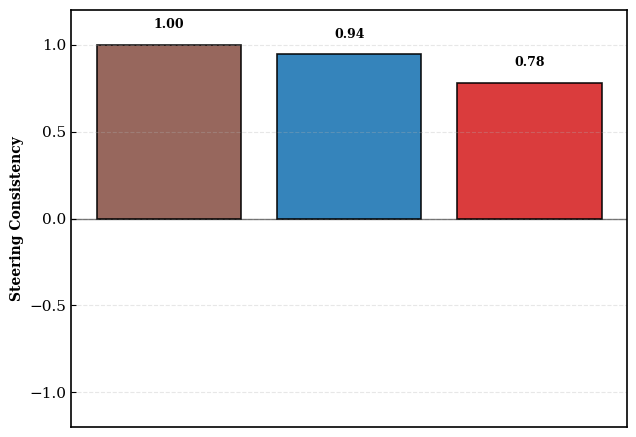

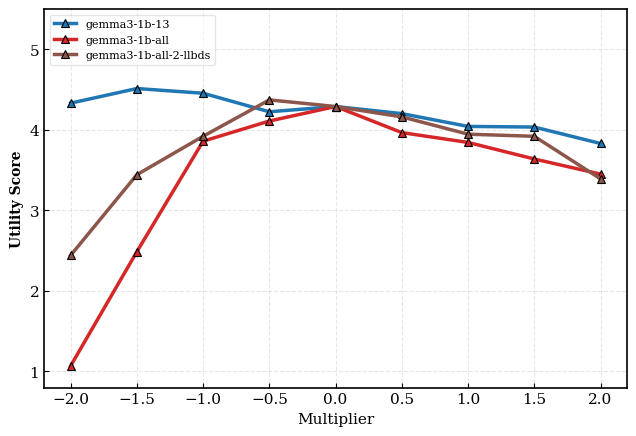

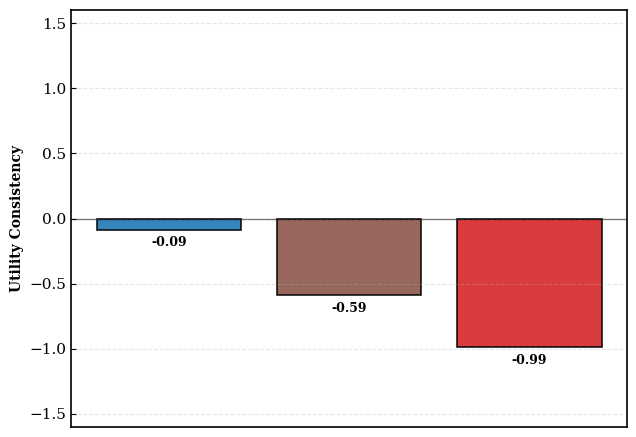

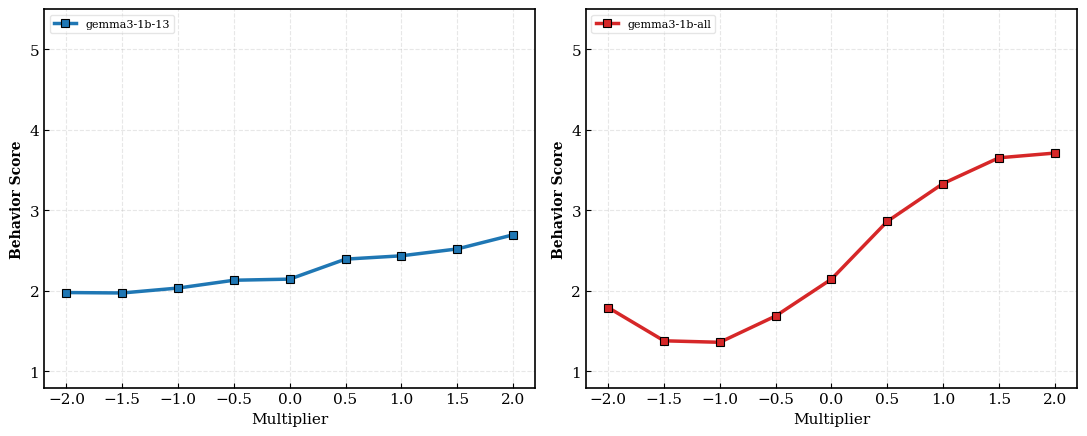

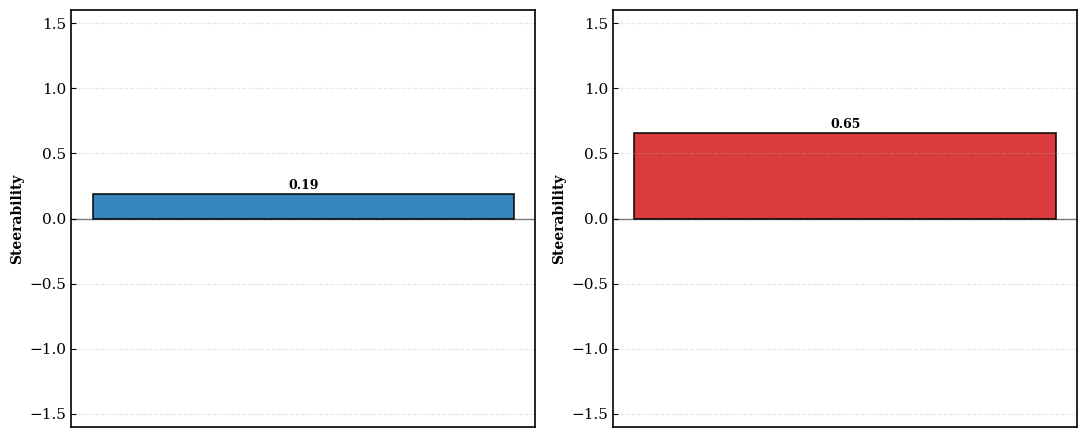

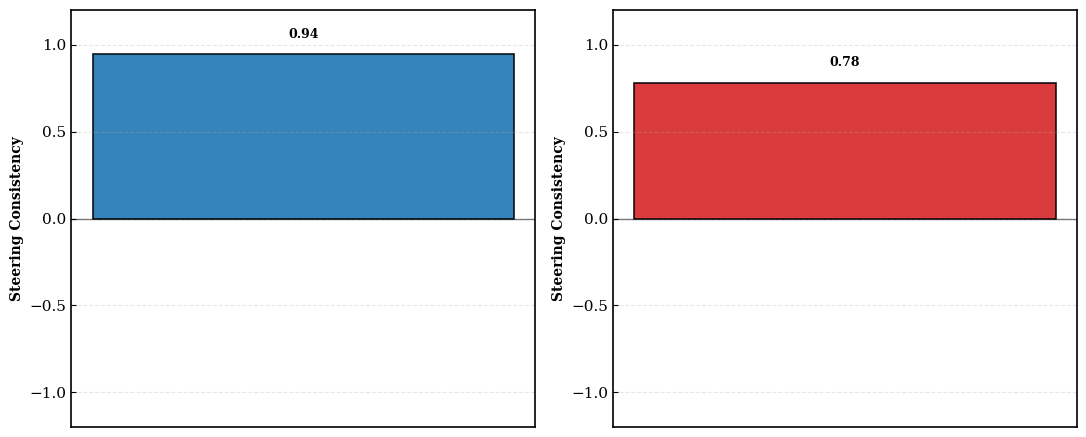

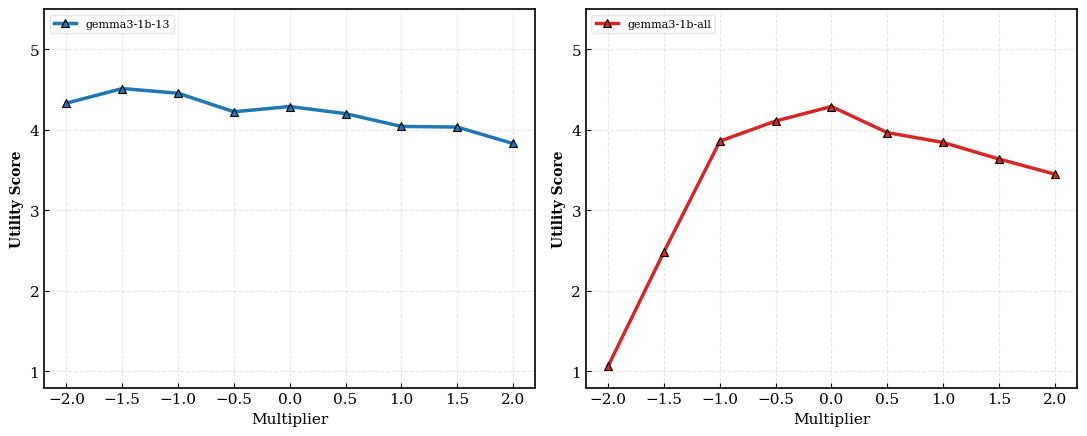

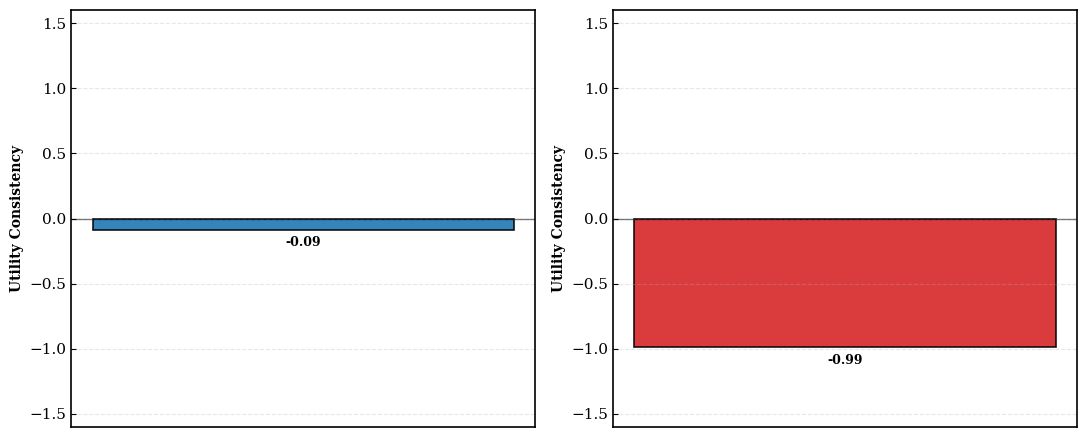

In [ ]:
plot_bipo_data_4th_column_alone(final_data_gemma)
del final_data_gemma['Final Comparison']
del final_data_gemma['k1 Ablation']
# plot_bipo_data(final_data_gemma)


In [24]:
if __name__ == "__main__":
    # Define parameters
    BASE_DIR ="../reasoning/survival-instinct/llama" 
    SCORE_COL = "Score" 
    ID_COL = "Question"
    
    FINAL_RESULT_DICT = {
        "Single Layer Ablation": ["llama3-1-8b-6","llama3-1-8b-16","llama3-1-8b-26"],
        "Scale Ablation": ["llama3-1-8b-all","llama3-1-8b-all-2","llama3-1-8b-all-3"],
        "k1 Ablation": ["llama3-1-8b-all-3","llama3-1-8b-all-3-llbds"],
        "Final Comparison": ["llama3-1-8b-16","llama3-1-8b-all","llama3-1-8b-all-3-llbds"],
    }

    
    BASELINES = ["llama3-1-8b-16", "llama3-1-8b-all"]

    # Run function and retrieve results
    final_data_llama, final_mcnemar_results = process_evaluation_data(
        base_dir=BASE_DIR,
        final_result_dict=FINAL_RESULT_DICT,
        score_column=SCORE_COL,
        id_column=ID_COL,
        baseline_subdirs=BASELINES
    )
 

Found 111 unique pairs to drop globally in Behavior.
  - Multiplier -2.0: 24 pairs
  - Multiplier -1.5: 37 pairs
  - Multiplier -1.0: 1 pairs
  - Multiplier -0.5: 4 pairs
  - Multiplier 0.0: 2 pairs
  - Multiplier 0.5: 8 pairs
  - Multiplier 1.0: 6 pairs
  - Multiplier 1.5: 20 pairs
  - Multiplier 2.0: 9 pairs
------------------------------
Found 120 unique pairs to drop globally in Utility.
  - Multiplier -2.0: 23 pairs
  - Multiplier -1.5: 29 pairs
  - Multiplier -1.0: 11 pairs
  - Multiplier -0.5: 6 pairs
  - Multiplier 0.5: 8 pairs
  - Multiplier 1.0: 8 pairs
  - Multiplier 1.5: 12 pairs
  - Multiplier 2.0: 23 pairs

=== POPULATED DATA_GEMMA KEYS ===
Single Layer Ablation:
  llama3-1-8b-6 -> Metrics found: []
  llama3-1-8b-16 -> Metrics found: ['behavior', 'utility']
  llama3-1-8b-26 -> Metrics found: []
Scale Ablation:
  llama3-1-8b-all -> Metrics found: ['behavior', 'utility']
  llama3-1-8b-all-2 -> Metrics found: []
  llama3-1-8b-all-3 -> Metrics found: []
k1 Ablation:
  llama3-

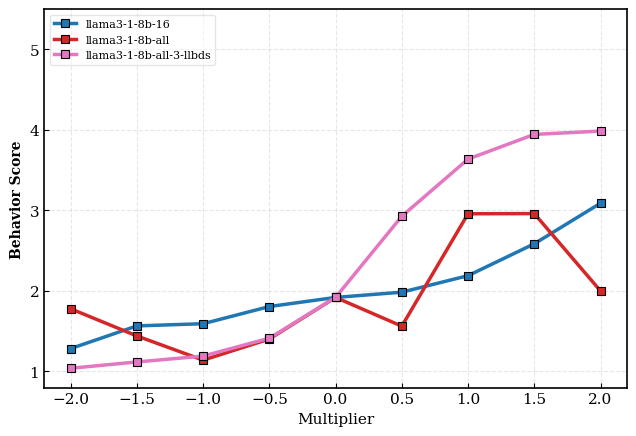

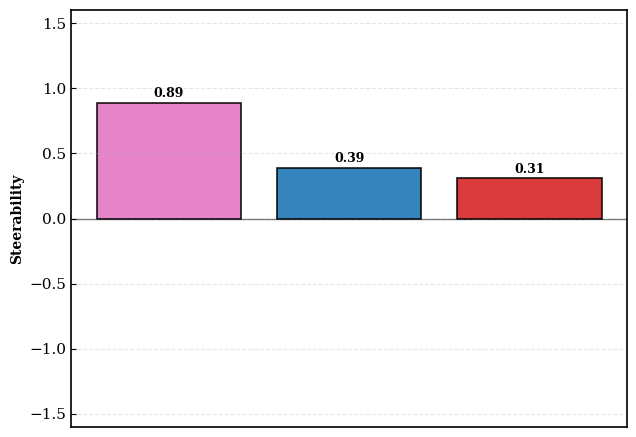

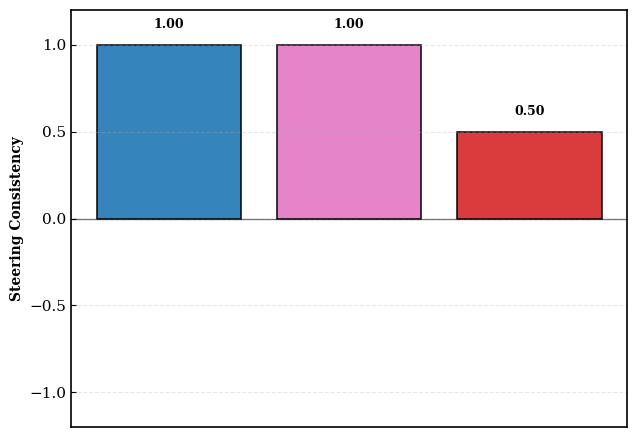

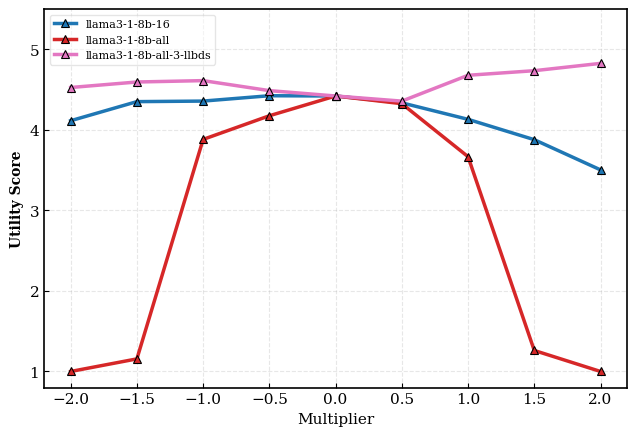

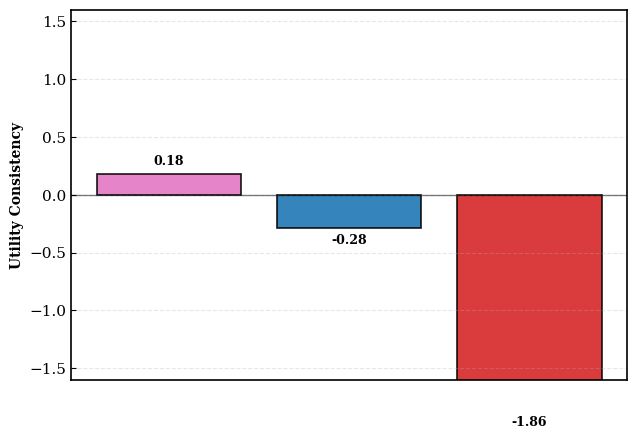

In [25]:
plot_bipo_data_4th_column_alone(final_data_llama)
del final_data_llama['Final Comparison']
del final_data_llama['k1 Ablation']
# plot_bipo_data(final_data_llama)


In [26]:
if __name__ == "__main__":
    # Define parameters
    BASE_DIR ="../reasoning/survival-instinct/mistral" 
    SCORE_COL = "Score" 
    ID_COL = "Question"
    
    FINAL_RESULT_DICT = {
        "Single Layer Ablation": ["mistral-7b-6","mistral-7b-16","mistral-7b-26"],
        "Scale Ablation": ["mistral-7b-all","mistral-7b-all-2","mistral-7b-all-3"],
        "k1 Ablation": ["mistral-7b-all-2","mistral-7b-all-2-llbds"],
        'Final Comparison': ["mistral-7b-6","mistral-7b-all","mistral-7b-all-2-llbds"],
    }

    
    BASELINES = ["mistral-7b-6", "mistral-7b-all"]

    # Run function and retrieve results
    final_data_mistral, final_mcnemar_results = process_evaluation_data(
        base_dir=BASE_DIR,
        final_result_dict=FINAL_RESULT_DICT,
        score_column=SCORE_COL,
        id_column=ID_COL,
        baseline_subdirs=BASELINES
    )
 

Found 39 unique pairs to drop globally in Behavior.
  - Multiplier -2.0: 1 pairs
  - Multiplier -1.5: 1 pairs
  - Multiplier -1.0: 4 pairs
  - Multiplier -0.5: 4 pairs
  - Multiplier 0.0: 3 pairs
  - Multiplier 0.5: 5 pairs
  - Multiplier 1.0: 5 pairs
  - Multiplier 1.5: 8 pairs
  - Multiplier 2.0: 8 pairs
------------------------------
Found 57 unique pairs to drop globally in Utility.
  - Multiplier -2.0: 6 pairs
  - Multiplier -1.5: 7 pairs
  - Multiplier -1.0: 2 pairs
  - Multiplier -0.5: 5 pairs
  - Multiplier 0.0: 2 pairs
  - Multiplier 0.5: 6 pairs
  - Multiplier 1.0: 6 pairs
  - Multiplier 1.5: 10 pairs
  - Multiplier 2.0: 13 pairs

=== POPULATED DATA_GEMMA KEYS ===
Single Layer Ablation:
  mistral-7b-6 -> Metrics found: ['behavior', 'utility']
  mistral-7b-16 -> Metrics found: []
  mistral-7b-26 -> Metrics found: []
Scale Ablation:
  mistral-7b-all -> Metrics found: ['behavior', 'utility']
  mistral-7b-all-2 -> Metrics found: []
  mistral-7b-all-3 -> Metrics found: []
k1 Ablat

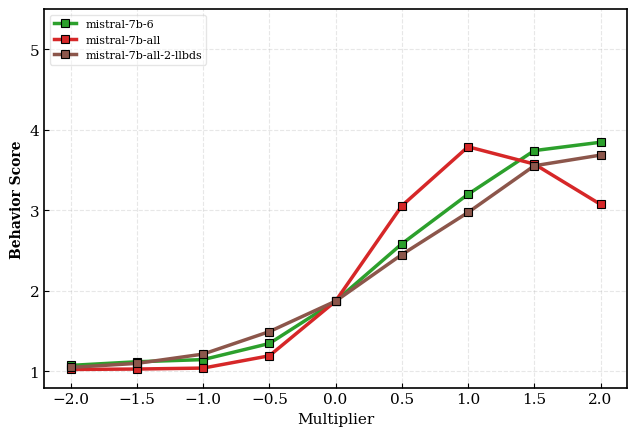

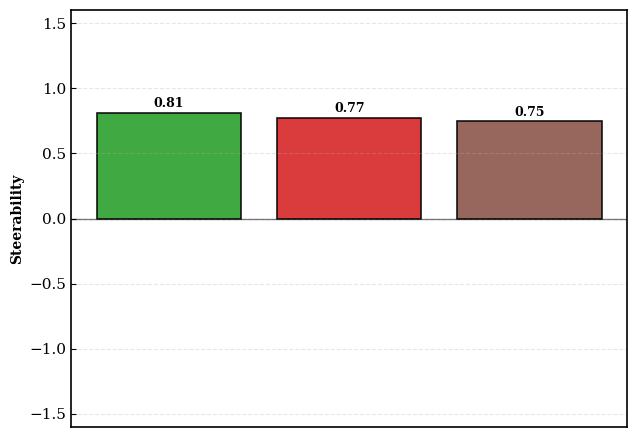

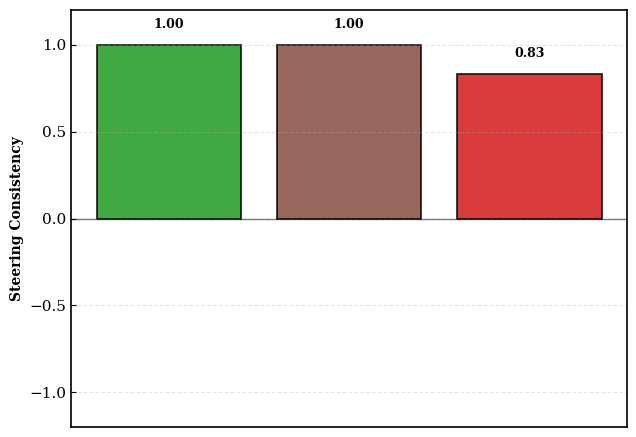

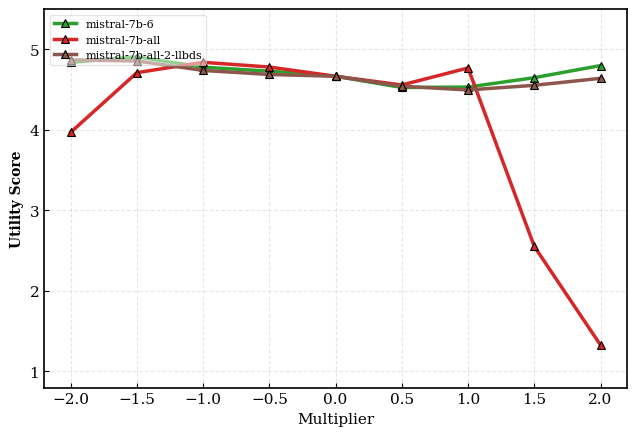

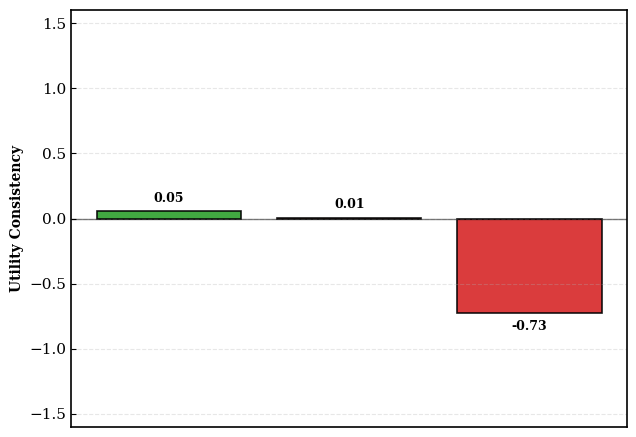

In [27]:
plot_bipo_data_4th_column_alone(final_data_mistral)
del final_data_mistral['Final Comparison']
del final_data_mistral['k1 Ablation']
# plot_bipo_data(final_data_mistral)
